# Marketing Campaign Analysis

**Business objective:** Identify the highest-impact ways to improve marketing performance using customer, campaign, spend, and channel data.

**Core question:** Where is the company wasting marketing budget, and which customers, channels, and campaigns should receive more focus?

**Analysis covers:**
1. Campaign effectiveness
2. RFM-based customer segmentation
3. High-value customer profiling
4. Channel performance
5. Churn and re-engagement signals

**Success output:** A CMO-ready analysis with key metrics, customer segments, commercial interpretation, and actionable recommendations.

In [2]:
#Importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

---

## 1. Load the Dataset

Load the raw CSV, inspect shape, column types, and missing values before any transformations.

In [3]:
#Loading the dataset
df = pd.read_csv('marketing_campaign.csv', sep='\t')
print("Number of datapoints: ", len(df))
df.head()

Number of datapoints:  2240


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
#Information on features
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [5]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
df.info()

---

## 2. Data Cleaning & Feature Engineering

Before analysing performance, we verify data quality across five dimensions:
- Missing values
- Duplicate rows
- Data types
- Suspicious values
- Outliers

### 2.1 Cleaning

**Income — outlier removal**

The maximum income value (€666,666) is an obvious data entry error — the 75th percentile sits at €68,522. We use the IQR method to identify outliers, remove only the extreme entry, then impute the 24 missing income values with the median.

The median is preferred over the mean here because the income distribution is right-skewed. A few high earners pull the mean upward, making it unrepresentative of the typical customer.

In [6]:
#Identify outliers in Income feature
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)
IQR = Q3 - Q1

upper = Q3 + 1.5 * IQR

outliers = df[(df['Income'] > upper)]

print(outliers[['Income']])

        Income
164   157243.0
617   162397.0
655   153924.0
687   160803.0
1300  157733.0
1653  157146.0
2132  156924.0
2233  666666.0


In [7]:
#Remove outlier in Income feature
df = df[(df['Income'] < 200000) | (df['Income'].isna())] 

In [8]:
#Replace empty values with meadian in Income feature
df['Income'] = df['Income'].fillna(df['Income'].median())

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2239 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2239 non-null   int64  
 1   Year_Birth           2239 non-null   int64  
 2   Education            2239 non-null   object 
 3   Marital_Status       2239 non-null   object 
 4   Income               2239 non-null   float64
 5   Kidhome              2239 non-null   int64  
 6   Teenhome             2239 non-null   int64  
 7   Dt_Customer          2239 non-null   object 
 8   Recency              2239 non-null   int64  
 9   MntWines             2239 non-null   int64  
 10  MntFruits            2239 non-null   int64  
 11  MntMeatProducts      2239 non-null   int64  
 12  MntFishProducts      2239 non-null   int64  
 13  MntSweetProducts     2239 non-null   int64  
 14  MntGoldProds         2239 non-null   int64  
 15  NumDealsPurchases    2239 non-null   int64 

In [10]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,...,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.0,2239.0,2239.000000
mean,5590.444841,1968.802144,51963.463600,0.443948,0.506476,49.121036,304.067441,26.307727,167.016525,37.538633,...,5.316213,0.072800,0.074587,0.072800,0.064314,0.013399,0.009379,3.0,11.0,0.149174
std,3246.372471,11.985494,21410.674611,0.538390,0.544555,28.963662,336.614830,39.781468,225.743829,54.637617,...,2.427144,0.259867,0.262782,0.259867,0.245367,0.115001,0.096412,0.0,0.0,0.356339
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2827.500000,1959.000000,35533.500000,0.000000,0.000000,24.000000,24.000000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5455.000000,1970.000000,51373.000000,0.000000,0.000000,49.000000,174.000000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8423.500000,1977.000000,68277.500000,1.000000,1.000000,74.000000,504.500000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,162397.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


**Marital status simplification**

Raw marital status contains several overlapping categories. We simplify to a binary flag: `1` for customers in a relationship (Married or Together), `0` for all others.

In [11]:
df['Marital_Status'].value_counts()

Marital_Status
Married     864
Together    579
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [12]:
def simplify_marital_status(status):
    if status in ['Married', 'Together']:
        return '1'
    else:
        return '0'

df['Marital_Status'] = df['Marital_Status'].apply(simplify_marital_status)
df['Marital_Status'].value_counts()

Marital_Status
1    1443
0     796
Name: count, dtype: int64

### 2.2 Feature Engineering

Five new features are derived to support RFM scoring and segmentation:

| Feature | Logic | Purpose |
|---|---|---|
| `Age` | `2014 - Year_Birth` | Demographic profiling. Calculated relative to dataset collection period (2012–2014), not current date, to avoid inflating ages artificially |
| `TotalSpend` | Sum of all 6 product spend columns | Monetary (M) component of RFM — most direct measure of customer value |
| `TotalPurchases` | Sum of web + store + catalogue purchases | Frequency (F) component of RFM — transaction volume across all channels |
| `HasChildren` | Binary flag from `Kidhome + Teenhome > 0` | Key demographic predictor of spend behaviour |
| `Total_Campaign_Accepts` | Sum of all 6 campaign response columns | Measures overall campaign engagement per customer |

In [13]:
df['Age'] = 2014 - df['Year_Birth']
df['TotalSpend'] = df[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum(axis=1)
df['TotalPurchases'] = df[['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']].sum(axis=1)
df['HasChildren'] = ((df['Kidhome'] + df['Teenhome']) > 0).astype(int)
df['Total_Campaign_Accepts'] = df[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']].sum(axis=1)

In [14]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,TotalSpend,TotalPurchases,HasChildren,Total_Campaign_Accepts
0,5524,1957,Graduation,0,58138.0,0,0,04-09-2012,58,635,...,0,0,3,11,1,57,1617,22,0,1
1,2174,1954,Graduation,0,46344.0,1,1,08-03-2014,38,11,...,0,0,3,11,0,60,27,4,1,0
2,4141,1965,Graduation,1,71613.0,0,0,21-08-2013,26,426,...,0,0,3,11,0,49,776,20,0,0
3,6182,1984,Graduation,1,26646.0,1,0,10-02-2014,26,11,...,0,0,3,11,0,30,53,6,1,0
4,5324,1981,PhD,1,58293.0,1,0,19-01-2014,94,173,...,0,0,3,11,0,33,422,14,1,0


In [15]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,TotalSpend,TotalPurchases,HasChildren,Total_Campaign_Accepts
count,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,...,2239.000000,2239.000000,2239.0,2239.0,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000
mean,5590.444841,1968.802144,51963.463600,0.443948,0.506476,49.121036,304.067441,26.307727,167.016525,37.538633,...,0.013399,0.009379,3.0,11.0,0.149174,45.197856,606.041090,12.539527,0.715051,0.447075
std,3246.372471,11.985494,21410.674611,0.538390,0.544555,28.963662,336.614830,39.781468,225.743829,54.637617,...,0.115001,0.096412,0.0,0.0,0.356339,11.985494,602.274089,7.206400,0.451491,0.890692
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,3.0,11.0,0.000000,18.000000,5.000000,0.000000,0.000000,0.000000
25%,2827.500000,1959.000000,35533.500000,0.000000,0.000000,24.000000,24.000000,1.000000,16.000000,3.000000,...,0.000000,0.000000,3.0,11.0,0.000000,37.000000,69.000000,6.000000,0.000000,0.000000
50%,5455.000000,1970.000000,51373.000000,0.000000,0.000000,49.000000,174.000000,8.000000,67.000000,12.000000,...,0.000000,0.000000,3.0,11.0,0.000000,44.000000,396.000000,12.000000,1.000000,0.000000
75%,8423.500000,1977.000000,68277.500000,1.000000,1.000000,74.000000,504.500000,33.000000,232.000000,50.000000,...,0.000000,0.000000,3.0,11.0,0.000000,55.000000,1046.000000,18.000000,1.000000,1.000000
max,11191.000000,1996.000000,162397.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,1.000000,1.000000,3.0,11.0,1.000000,121.000000,2525.000000,32.000000,1.000000,5.000000


**Age outlier removal**

There is at least one customer with an unrealistic age (>100), almost certainly a data entry error in `Year_Birth`. These records are removed.

In [16]:
df = df[df['Age'] < 100]

In [17]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,TotalSpend,TotalPurchases,HasChildren,Total_Campaign_Accepts
count,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.00000,2236.000000,2236.000000,2236.000000,...,2236.000000,2236.000000,2236.0,2236.0,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000
mean,5589.008497,1968.898032,51952.522809,0.444097,0.506708,49.116279,304.12746,26.275939,166.983453,37.536225,...,0.013417,0.008945,3.0,11.0,0.149374,45.101968,605.986583,12.546512,0.715116,0.447227
std,3244.826887,11.703281,21411.469303,0.538459,0.544609,28.957284,336.59181,39.724007,225.689645,54.648562,...,0.115077,0.094173,0.0,0.0,0.356536,11.703281,601.865156,7.206577,0.451460,0.891113
min,0.000000,1940.000000,1730.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,3.0,11.0,0.000000,18.000000,5.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,35502.500000,0.000000,0.000000,24.000000,24.00000,1.000000,16.000000,3.000000,...,0.000000,0.000000,3.0,11.0,0.000000,37.000000,69.000000,6.000000,0.000000,0.000000
50%,5454.500000,1970.000000,51373.000000,0.000000,0.000000,49.000000,174.00000,8.000000,67.000000,12.000000,...,0.000000,0.000000,3.0,11.0,0.000000,44.000000,396.500000,12.000000,1.000000,0.000000
75%,8421.750000,1977.000000,68275.750000,1.000000,1.000000,74.000000,504.25000,33.000000,232.000000,50.000000,...,0.000000,0.000000,3.0,11.0,0.000000,55.000000,1045.500000,18.000000,1.000000,1.000000
max,11191.000000,1996.000000,162397.000000,2.000000,2.000000,99.000000,1493.00000,199.000000,1725.000000,259.000000,...,1.000000,1.000000,3.0,11.0,1.000000,74.000000,2525.000000,32.000000,1.000000,5.000000


---

## 3. Exploratory Data Analysis

With clean data and engineered features, we explore the customer base to answer:
- How valuable is the average customer, and is spend concentrated in a small group?
- Which product categories dominate?
- How do income, family status, and recency relate to spend and campaign response?

Rather than plotting all 29 columns, analysis focuses on the five variables most directly connected to the core business question.

### 3.1 Univariate Analysis

**Variables selected:**
- `Income` — strongest demographic predictor of customer value
- `Age` — key demographic for segmentation and targeting
- `TotalSpend` — monetary (M) component of RFM
- `TotalPurchases` — frequency (F) component of RFM
- `Recency` — recency (R) component of RFM

<Axes: xlabel='Age', ylabel='Count'>

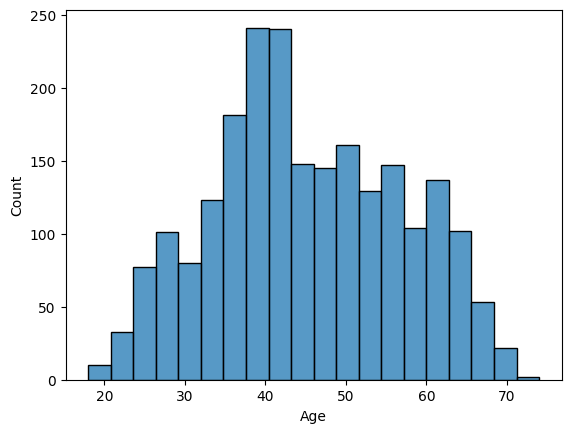

In [18]:
# Age distribution
sns.histplot(df['Age'], bins=20)

**Age:** Distribution peaks at 35–45 with a right-skewed tail toward older ages. No extreme outliers remain after cleaning.

<Axes: xlabel='Income', ylabel='Count'>

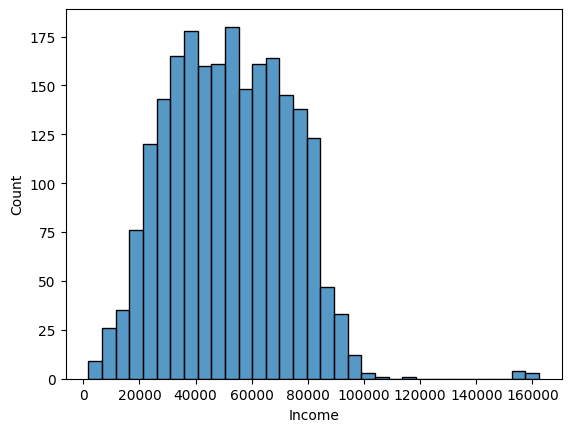

In [19]:
sns.histplot(df['Income'])

**Income:** Right-skewed distribution with a long tail toward higher earners (~€160k range). No strong central peak, income is spread across a wide range.

<Axes: xlabel='TotalSpend', ylabel='Count'>

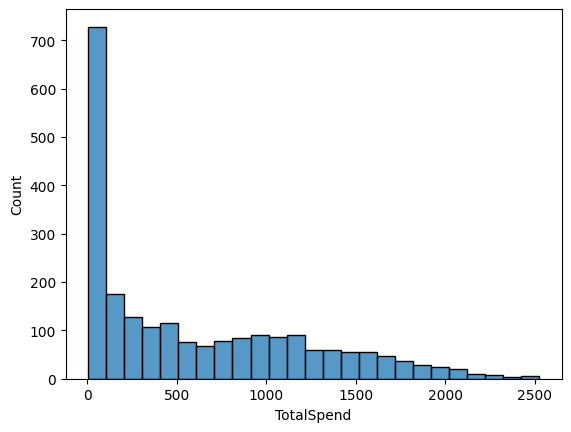

In [20]:
sns.histplot(df['TotalSpend'], bins=25)

**TotalSpend:** Highly concentrated at the low end. Most customers spend €100 or less, suggesting a classic 80/20 pattern where a small minority of high-spending customers drive the majority of revenue.

<Axes: xlabel='TotalPurchases', ylabel='Count'>

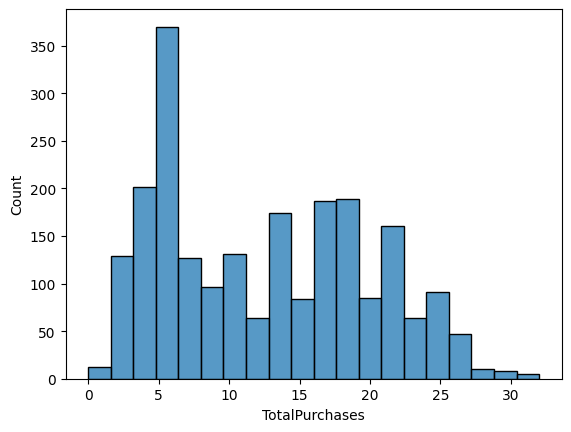

In [21]:
sns.histplot(df['TotalPurchases'], bins=20)

**TotalPurchases:** Bimodal distribution with peaks around 5 and 15–18 transactions. This hints at two distinct customer types: low-frequency and high-frequency buyers.

<Axes: xlabel='Recency', ylabel='Count'>

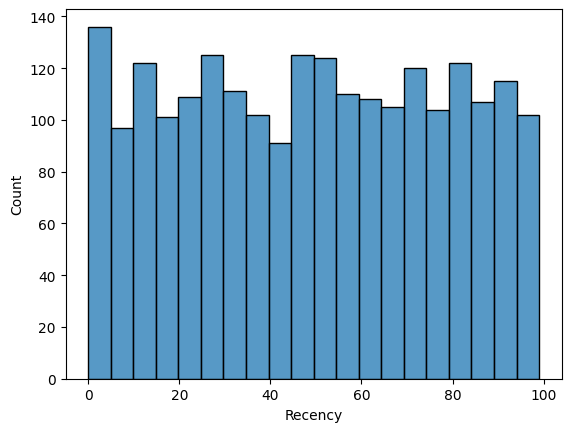

In [22]:
sns.histplot(df['Recency'], bins=20)

**Recency:** Roughly uniform distribution across all recency values. No strong clustering at any particular interval. The database contains an even mix of recently active and dormant customers. Recency alone cannot identify valuable customers, which is why it must be combined with frequency and monetary value in RFM scoring.

### 3.2 Bivariate Analysis

<Axes: xlabel='Income', ylabel='TotalSpend'>

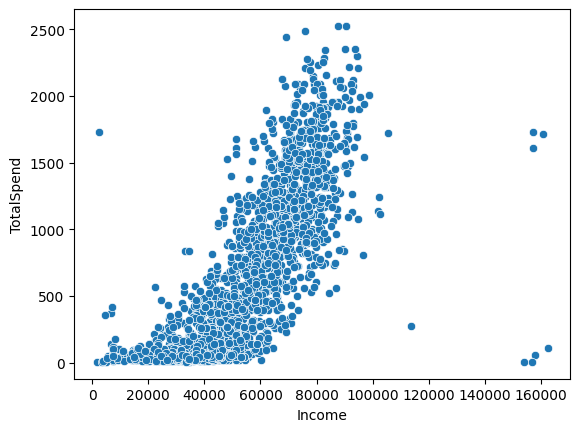

In [23]:
sns.scatterplot(data=df, x='Income', y='TotalSpend')

**Income vs. TotalSpend:** Clear positive linear relationship. Higher-income customers tend to spend more, with the exception of a few very high earners (€150k+) who spend surprisingly little. Income alone is not sufficient for targeting.

<Axes: xlabel='HasChildren'>

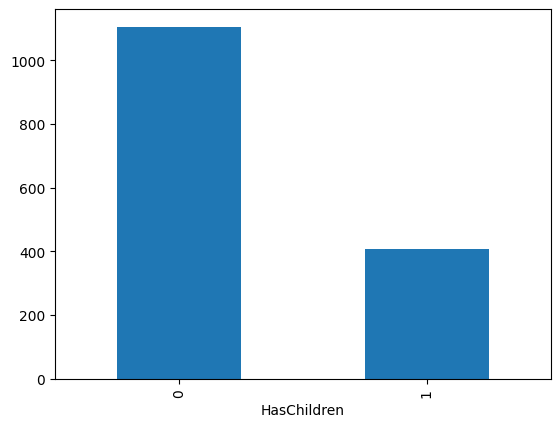

In [24]:
#Average spend by households with vs. without children
df.groupby('HasChildren')['TotalSpend'].mean().plot(kind='bar')

**Children vs. Spend:** Customers without children spend ~2.7× more on average (€1,100 vs. €400). Family status is a stronger spend predictor than income alone.

<Axes: xlabel='Response'>

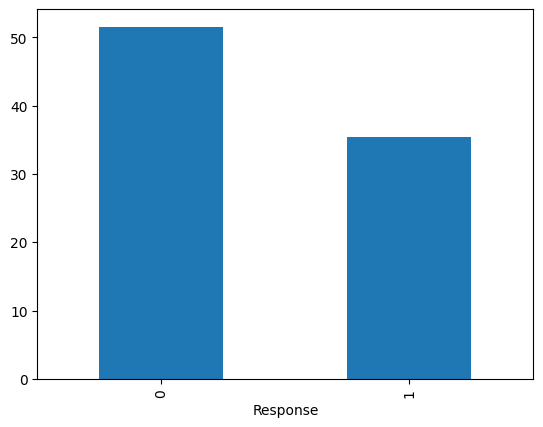

In [25]:
df.groupby('Response')['Recency'].mean().plot(kind='bar')

**Recency vs. Campaign Response:** Customers who responded to the latest campaign made their most recent purchase an average of 35 days ago, compared to 50 days for non-responders. Campaign timing relative to last purchase date is a key lever. Recency-triggered campaigns are likely to outperform batch sends.

<Axes: >

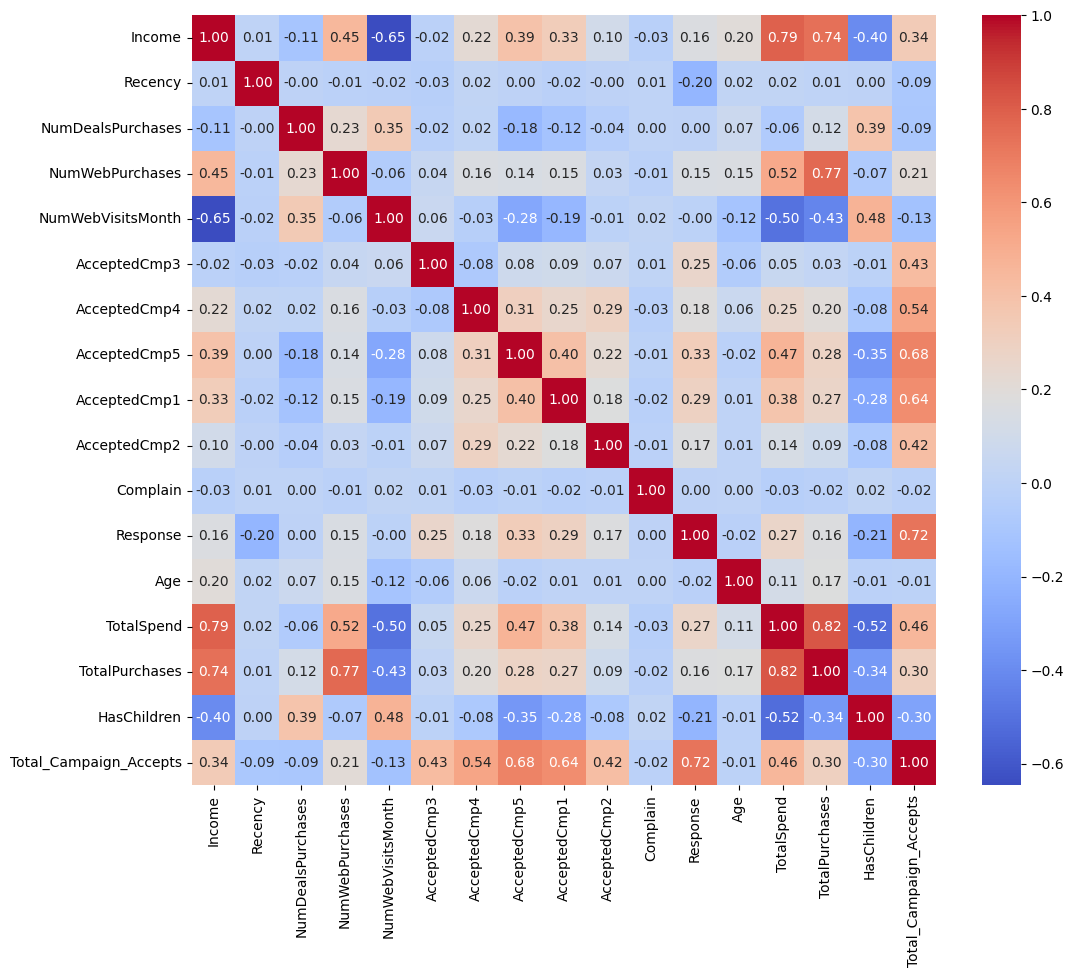

In [27]:
df_corr = df.select_dtypes(include='number').corr()

drop_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
            'NumCatalogPurchases', 'NumStorePurchases',
            'Year_Birth',
            'Z_CostContact', 'Z_Revenue',
            'Kidhome', 'Teenhome',
            'ID']

plt.figure(figsize=(12, 10))
sns.heatmap(df_corr.drop(index=drop_cols, columns=drop_cols), cmap="coolwarm", annot=True, fmt=".2f")

**Correlation heatmap:** Key relationships:
- `Income` is strongly positively correlated with `TotalSpend` and `TotalPurchases`
- `NumWebVisitsMonth` is strongly **negatively** correlated with spend. High web traffic does not convert to purchases. Frequent visitors are browsers, not buyers
- `HasChildren` is negatively correlated with `TotalSpend`, consistent with the bivariate finding above
- Campaign acceptance columns correlate with each other (strongest: Cmp1 and Cmp5 at 0.4). Customers who accepted earlier campaigns are more likely to accept future ones

### 3.3 EDA Summary

| # | Finding | Implication |
|---|---|---|
| 1 | Income and spend are linearly related, but some high earners spend little | Income is useful for targeting but not sufficient on its own |
| 2 | Child-free customers spend 2.7× more | Family status should be a primary segmentation variable |
| 3 | Recent purchasers respond better to campaigns | Recency-triggered sends will outperform full-database campaigns |
| 4 | Spend is concentrated, likely 80/20 distribution | Segmentation will matter more than broad discounting |
| 5 | Recency is uniformly distributed | Cannot target on recency alone. RFM combination required |

These patterns form the hypotheses tested formally in sections 4 and 5.

---

## 4. RFM Segmentation

Each customer receives three scores: Recency (R), Frequency (F), and Monetary Value (M) based on their relative position within the dataset, using quartile-based scoring (`pd.qcut`).

**Scoring logic:**
- Scores range from 1 to 4 per dimension (4 = most desirable behaviour)
- Recency scores are **inverted** (lower recency = more recent purchase = better), so a customer who purchased yesterday gets R=4
- The three scores are summed into a composite RFM score (range: 3–12)
- Customers are assigned to one of four segments based on score bands:

| Score Band | Segment |
|---|---|
| 3–5 | At Risk |
| 6–7 | Occasional |
| 8–9 | Active |
| 10–12 | Champions |

`pd.qcut` is used (rather than `pd.cut`) to ensure each score band contains approximately equal numbers of customers, preventing any single quartile from dominating.

In [28]:
df['R_Score'] = pd.qcut(df['Recency'], q=4, labels=[4,3,2,1]).astype(int)
df['F_Score'] = pd.qcut(df['TotalPurchases'], q=4, labels=[1,2,3,4]).astype(int)
df['M_Score'] = pd.qcut(df['TotalSpend'], q=4, labels=[1,2,3,4]).astype(int)

df['RFM_Score'] = df['R_Score'] + df['F_Score'] + df['M_Score']
df['Segment'] = pd.cut(df['RFM_Score'], bins=[2,5,7,9,12], labels=['At Risk', 'Occasional', 'Active', 'Champions'])

In [29]:
df['Segment'].value_counts()

Segment
Active        607
At Risk       600
Champions     537
Occasional    492
Name: count, dtype: int64

**Validation RFM dimensions by segment:**

The chart below confirms segmentation logic is working. Note that for Recency, lower values are better. Champions show the lowest average recency (~28 days), meaning they purchased most recently.

One expected quirk: Occasional customers show slightly lower recency than Active customers. This occurs because RFM combines three dimensions simultaneously. A customer can have low recency but very low frequency and spend, landing them in Occasional rather than Active. The combined score is the correct signal.

Text(0.5, 1.0, 'Monetary Value')

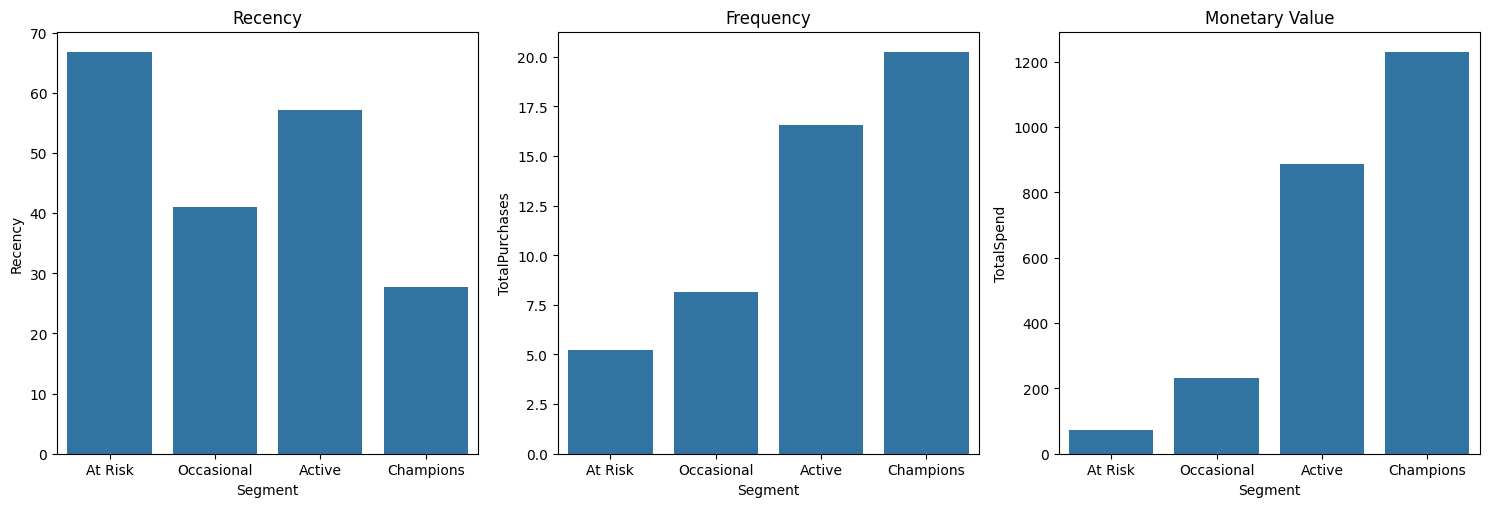

In [30]:
R_plot = df.groupby('Segment', observed=True)['Recency'].mean()
F_plot = df.groupby('Segment', observed=True)['TotalPurchases'].mean()
M_plot = df.groupby('Segment', observed=True)['TotalSpend'].mean()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.barplot(data=R_plot, ax=axes[0])
sns.barplot(data=F_plot, ax=axes[1])
sns.barplot(data=M_plot, ax=axes[2])

plt.tight_layout()

axes[0].set_title("Recency")
axes[1].set_title("Frequency")
axes[2].set_title("Monetary Value")

---

## 5. Segment Profiling

With segments defined, we build a full demographic and behavioural profile for each group to identify the Ideal Customer Profile (ICP) and the highest-priority re-engagement targets.

In [31]:
segment_profiles = df.groupby("Segment", observed=True).agg(
    avg_recency=("Recency", "mean"),
    avg_purchases=("TotalPurchases", "mean"),
    avg_spend=("TotalSpend", "mean"),
    customers=("ID", "count"),
    avg_income=("Income", "mean"),
    avg_age=("Age", "mean"),
    avg_pct_has_kids=("HasChildren", lambda x: x.mean() * 100),
    response_rate=("Response", lambda x: x.mean() * 100),
    multi_campaign_accept_rate=("Total_Campaign_Accepts", lambda x: (x >= 2).mean() * 100)
)

display(round(segment_profiles,2))

,avg_recency,avg_purchases,avg_spend,customers,avg_income,avg_age,avg_pct_has_kids,response_rate,multi_campaign_accept_rate
Segment,,,,,,,,,
At Risk,66.83,5.22,72.50,600,33716.31,42.89,90.00,3.67,2.17
Occasional,41.05,8.12,230.35,492,41299.13,43.67,82.52,12.20,4.27
Active,57.11,16.54,885.56,607,61921.82,47.12,65.24,15.65,12.52
Champions,27.68,20.26,1230.22,537,70820.00,46.60,47.86,29.24,24.02


In [32]:
education_profile = pd.crosstab(df['Segment'], df['Education'], normalize='index')

Text(0.5, 1.0, 'Education Level per Segment')

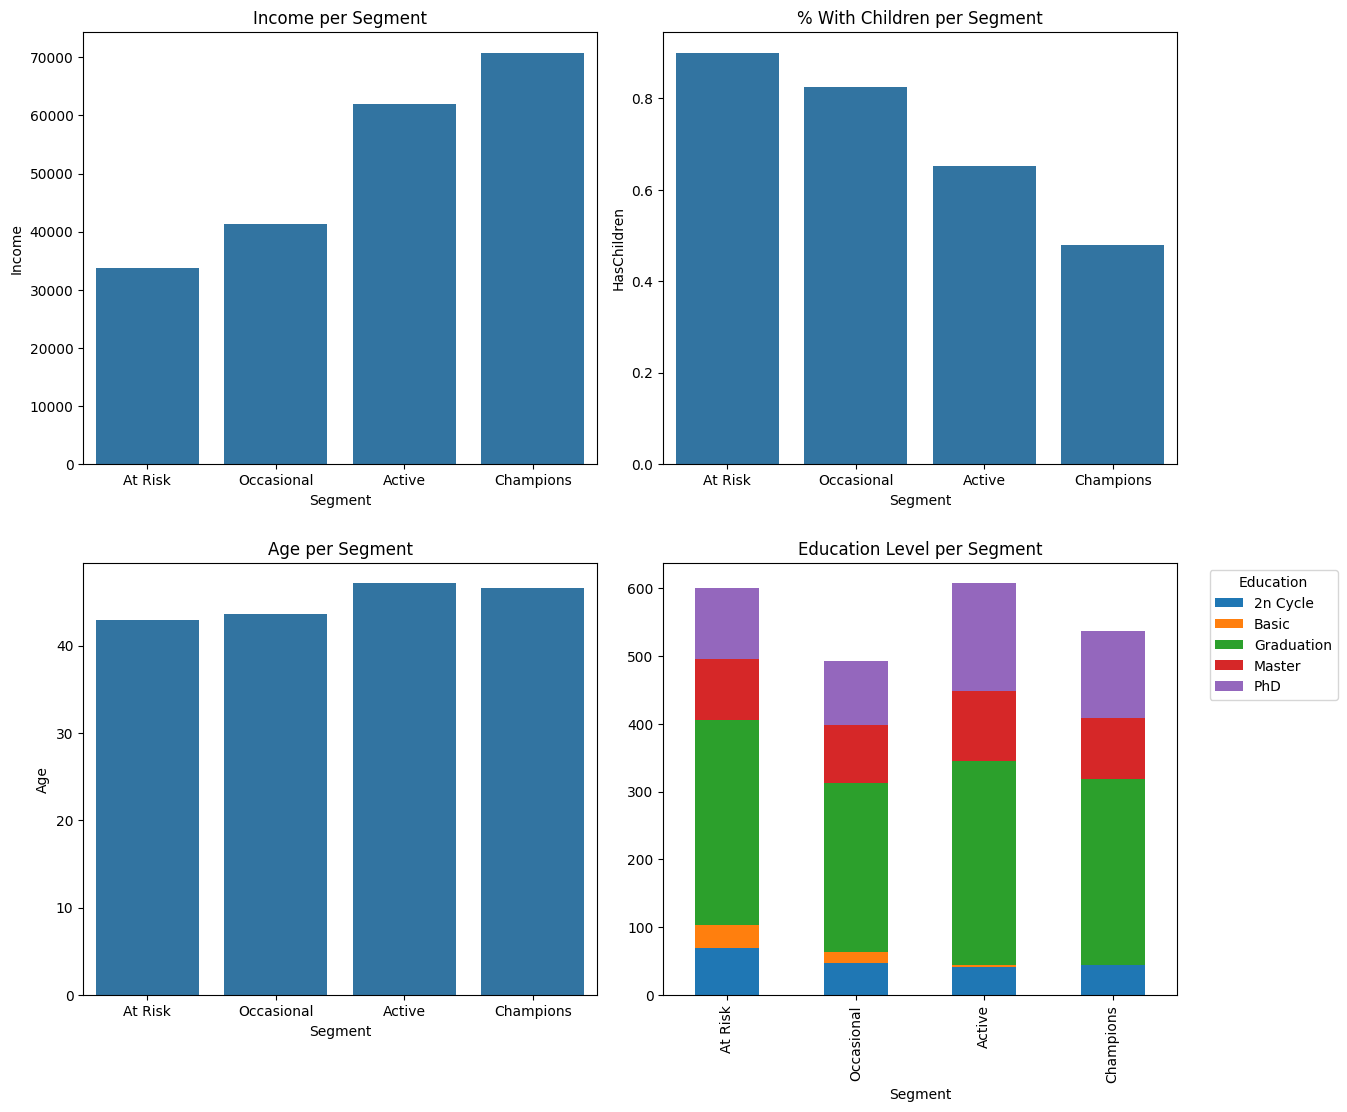

In [33]:
Segments_Income = df.groupby('Segment', observed=True)['Income'].mean()
Segments_Children = df.groupby('Segment', observed=True)['HasChildren'].mean()
Segments_Age = df.groupby('Segment', observed=True)['Age'].mean()
Segments_Education = pd.crosstab(df['Segment'], df['Education'])

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

sns.barplot(data=Segments_Income, ax=axes[0,0])
sns.barplot(data=Segments_Children, ax=axes[0,1])
sns.barplot(data=Segments_Age, ax=axes[1,0])

# Education plot
Segments_Education.plot(kind='bar', stacked=True, ax=axes[1,1], legend=True)
axes[1, 1].legend(title="Education", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout(rect=[0, 0, 0.85, 1], h_pad=4)

axes[0,0].set_title("Income per Segment")
axes[0,1].set_title("% With Children per Segment")
axes[1,0].set_title("Age per Segment")
axes[1,1].set_title("Education Level per Segment")


**High Value At Risk — sub-segment identification**

Within the At Risk segment, customers with F_Score ≥ 2 and M_Score ≥ 2 are flagged as "High Value At Risk." These are lapsed Champions: customers who historically purchased frequently and spent significantly, but whose recency has dropped. They carry the highest recovery potential of any At Risk sub-group.

In [44]:
#High Value At Risk customers - best potential to convert with retargeting
at_risk = df['Segment'] == 'At Risk'
high_value = (df['F_Score'] >= 2) & (df['M_Score'] >= 2)

high_value_atrisk = df[at_risk & high_value]
other_high_risk = df[at_risk & ~high_value]

In [45]:
comparison_df = pd.concat([
    high_value_atrisk.assign(Risk_Group='High Value At Risk'),
    other_high_risk.assign(Risk_Group='Other At Risk')
])

# Keep only At Risk customers
df_subset = df[df['Segment'] == 'At Risk']

risk_profiles = comparison_df.groupby('Risk_Group', observed=True).agg(
    avg_recency=("Recency", "mean"),
    avg_purchases=("TotalPurchases", "mean"),
    avg_spend=("TotalSpend", "mean"),
    customers=("ID", "count"),
    avg_income=("Income", "mean"),
    avg_age=("Age", "mean"),
    avg_pct_has_kids=("HasChildren",  lambda x: x.mean() * 100)
)

education_profile = pd.crosstab(
    comparison_df['Risk_Group'],
    comparison_df['Education'],
    normalize='index'
) * 100

full_profile = risk_profiles.join(education_profile)

display(full_profile.round(2))

,avg_recency,avg_purchases,avg_spend,customers,avg_income,avg_age,avg_pct_has_kids,2n Cycle,Basic,Graduation,Master,PhD
Risk_Group,,,,,,,,,,,,
High Value At Risk,87.28,9.03,207.89,87,43944.89,46.95,89.66,16.09,1.15,43.68,20.69,18.39
Other At Risk,63.37,4.58,49.53,513,31981.64,42.20,90.06,10.72,6.43,51.46,14.23,17.15


### 5.1 Key Findings

**Segment size vs. value gap:**
All four segments contain 490–607 customers, group sizes are roughly equal. But Champions spend 17× more than At Risk customers. Volume-based targeting (contact everyone equally) is therefore the primary source of wasted budget.

At €3 per contact, targeting all 2,236 customers costs €6,708 per campaign. Restricting to Champions + Active (1,144 customers) costs €3,432, a saving of €3,276 per campaign, with higher expected revenue given 29% and 16% response rates vs. the 7.5% full-database average.

---

**Champions, Ideal Customer Profile (ICP):**
- Average income ~€70k (vs. ~€33k for At Risk, more than double)
- 48% have children vs. 90% in the At Risk segment. Champions are significantly more likely to be child-free
- Average age ~47, similar across all segments. Age is not a useful differentiator
- Education level is distributed evenly across segments. Also not a useful targeting variable

**The ICP is a high-income (~€70k), child-free individual in their mid-40s who purchased within the last 30 days. Campaigns targeting this profile can expect ~29% response rates.**

---

**At Risk Win-Back Profile:**
- Average income ~€33k, 90% have children, average recency 67 days
- At 67 days average recency, they are approaching full churn. A win-back trigger at 45 days (before the threshold) gives the best recovery window
- Campaign 3 showed relatively higher At Risk engagement than other campaigns Its creative elements should anchor win-back messaging
- Category-specific offers on Wines or Meat (the dominant spend categories) are recommended over generic discounts

---

**High Value At Risk, Recovery Opportunity:**

| Metric | Value |
|---|---|
| Customers | 87 |
| Avg recency | 88 days |
| Avg spend | €207 |
| Contact cost | €261 (87 × €3) |
| Current total spend | €18,009 |
| If recovered to Active level | €76,995 |
| **Recovery opportunity** | **€58,986** |

These customers respond to quality and product selection rather than discounts. A catalogue-format offer with premium product curation is likely to outperform a generic discount campaign.

---

## 6. Campaign Effectiveness

Each of the 6 campaigns is evaluated on: response rate, estimated revenue, estimated contact cost, estimated profit, and ROI ratio.

**Revenue proxy assumptions:**
- Cost per contact: `Z_CostContact` median (€3)
- Revenue per acceptance: `Z_Revenue` median (€11)
- All campaigns assumed to contact the full database (dataset does not specify targeting lists)

These figures should be treated as directional estimates, not exact campaign financials.

<Axes: xlabel='Total_Campaign_Accepts'>

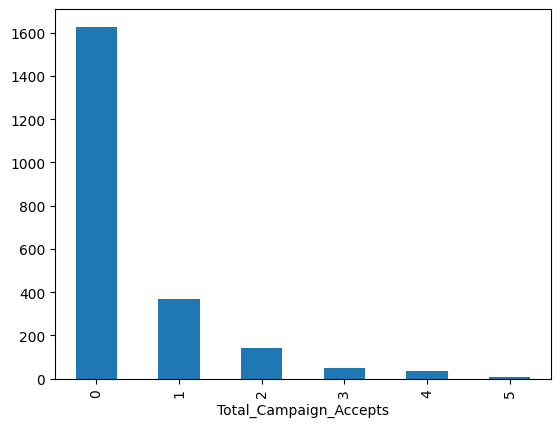

In [46]:
df['Total_Campaign_Accepts'].value_counts().plot(kind='bar')

<Axes: >

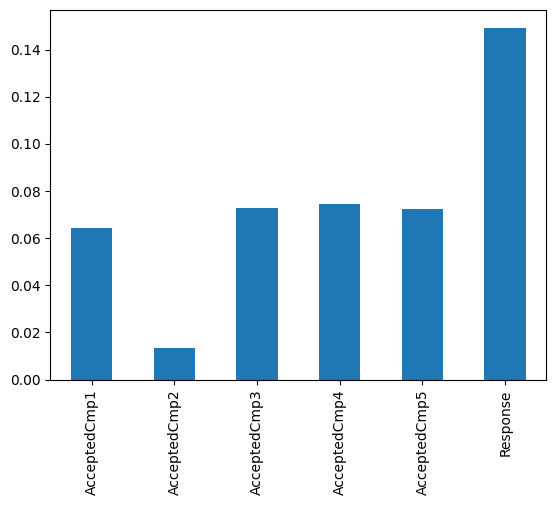

In [47]:
#Campaign effectiveness

#Campaign columns
campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']
df[campaign_cols].mean().plot(kind='bar')

In [48]:
campaign_performance = []

for col in campaign_cols:
    contacts = len(df)
    acceptors = df[col].sum()
    response_rate = df[col].mean()
    cost = contacts * df["Z_CostContact"].median()
    revenue = acceptors * df["Z_Revenue"].median()
    profit = revenue - cost
    roi_ratio = revenue / cost if cost > 0 else np.nan

    campaign_performance.append({
        "campaign": col,
        "contacts_assumed": contacts,
        "acceptors": acceptors,
        "response_rate": response_rate * 100,
        "estimated_cost": cost,
        "estimated_revenue": revenue,
        "estimated_profit": profit,
        "revenue_to_cost_ratio": roi_ratio * 100
    })

campaign_perf = pd.DataFrame(campaign_performance).sort_values("response_rate", ascending=False)
display(round(campaign_perf,2))

,campaign,contacts_assumed,acceptors,response_rate,estimated_cost,estimated_revenue,estimated_profit,revenue_to_cost_ratio
5,Response,2236,334,14.94,6708.0,3674.0,-3034.0,54.77
3,AcceptedCmp4,2236,167,7.47,6708.0,1837.0,-4871.0,27.39
2,AcceptedCmp3,2236,163,7.29,6708.0,1793.0,-4915.0,26.73
4,AcceptedCmp5,2236,162,7.25,6708.0,1782.0,-4926.0,26.57
0,AcceptedCmp1,2236,144,6.44,6708.0,1584.0,-5124.0,23.61
1,AcceptedCmp2,2236,30,1.34,6708.0,330.0,-6378.0,4.92


<Axes: >

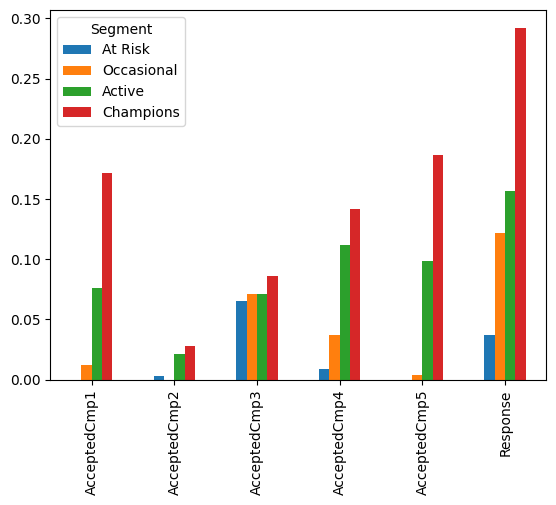

In [49]:
df.groupby('Segment', observed=True)[campaign_cols].mean().T.plot(kind='bar')

### 6.1 Key Findings

**Campaign 2, discontinue immediately:**
Response rate of 1.34%, the lowest across every segment. At full-database scale, this wastes €6,708 in contact costs for 30 acceptances. No segment responded well enough to justify continuing.

**Final campaign, replicate the format:**
Response rate of 14.94% overall, nearly double the average. Champions responded at 29%, but crucially, every other segment also improved. Occasional customers jumped from near 0% to 12%, and Active from ~10% to 16%. This suggests the campaign's design, offer, or timing was structurally superior, not just effective with already-engaged customers.

**Full-database targeting is structurally unprofitable:**
Every single campaign runs at a net loss when sent to the full customer base. At 7.45% average response, the revenue generated per campaign does not cover contact costs across 2,236 customers. Segmented targeting is the only path to positive ROI.

**At Risk segment, Campaign 3 signal:**
The At Risk segment showed relatively higher engagement with Campaign 3 compared to other campaigns. This is useful creative intelligence for future win-back messaging.

---

## 7. Product Category Analysis

This section identifies what customers are actually spending on, informing campaign creative and offer strategy.

<Axes: >

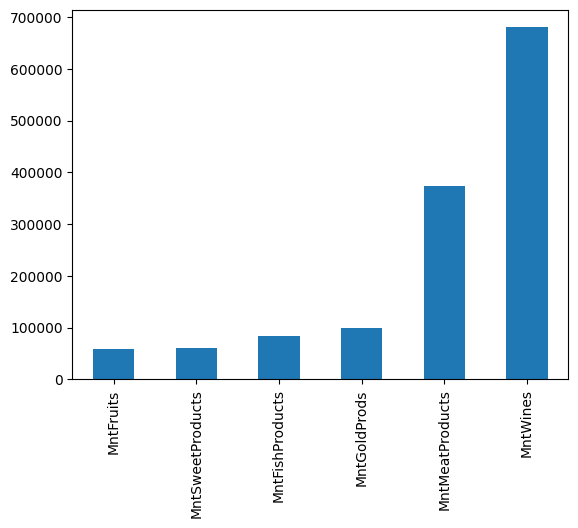

In [50]:
product_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df[product_cols].sum().sort_values().plot(kind='bar')

<Axes: xlabel='Segment'>

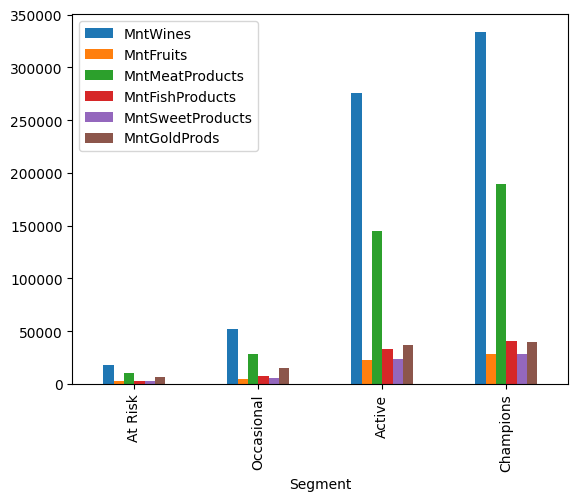

In [51]:
df.groupby('Segment', observed=True)[product_cols].sum().plot(kind='bar')

### 7.1 Key Findings

**Revenue by category:**
- Wines: €676k (~50% of total product revenue), dominant by a large margin
- Meat Products: €370k (second place)
- Fruits, Sweets, and Fish combined: less than 15% of total spend

**Implication for campaign strategy:**
Wines and Meat should anchor campaign creative and offers. Fruits, Sweets, and Fish should be treated as cross-sell additions bundled with wine purchases, not as standalone campaign hooks.

---

## 8. Channel Performance

This section identifies which purchase channels customers use most and how channel preferences vary by segment.

In [52]:
channels = ['NumWebPurchases', 'NumStorePurchases', 'NumCatalogPurchases']
df[channels].sum()

NumWebPurchases         9140
NumStorePurchases      12959
NumCatalogPurchases     5955
dtype: int64

<Axes: >

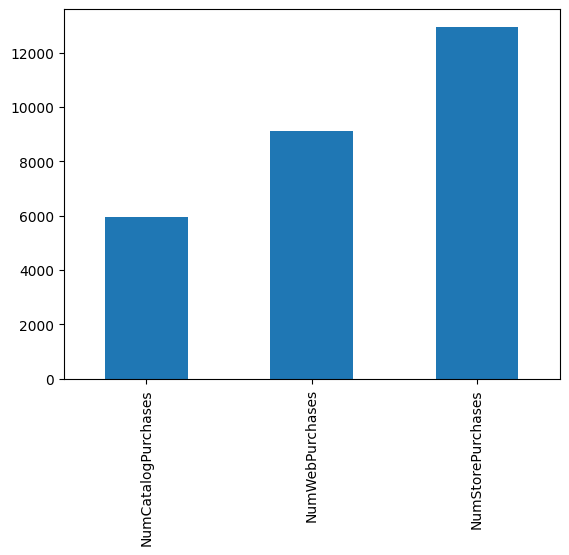

In [53]:
channels = ['NumWebPurchases', 'NumStorePurchases', 'NumCatalogPurchases']
df[channels].sum().sort_values().plot(kind='bar')

<Axes: xlabel='Segment'>

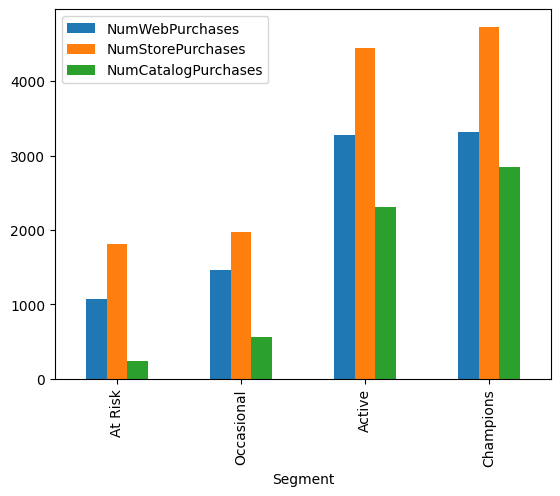

In [54]:
df.groupby('Segment', observed=True)[channels].sum().plot(kind='bar')

In [55]:
# Average channel usage by segment
df.groupby('Segment', observed=True)[channels + ['NumWebVisitsMonth', 'TotalSpend']].mean()

,NumWebPurchases,NumStorePurchases,NumCatalogPurchases,NumWebVisitsMonth,TotalSpend
Segment,,,,,
At Risk,1.798333,3.015000,0.411667,6.426667,72.495000
Occasional,2.979675,4.012195,1.132114,6.093496,230.345528
Active,5.406919,7.331137,3.805601,4.714992,885.556837
Champions,6.169460,8.800745,5.290503,4.054004,1230.216015


<Axes: xlabel='NumWebVisitsMonth', ylabel='NumWebPurchases'>

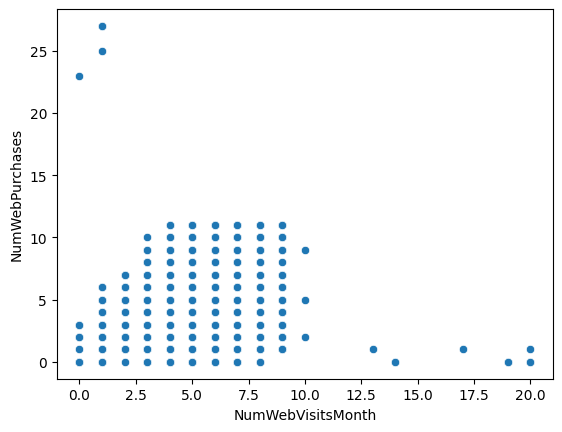

In [56]:
sns.scatterplot(data=df, x='NumWebVisitsMonth', y='NumWebPurchases')

### 8.1 Key Findings

**Store is the dominant channel** (13k transactions, 46% of total), followed by Web (9k) and Catalogue (6k). In-store promotions should anchor the channel strategy, not be treated as secondary to digital.

**Champions are disproportionately heavy catalogue users.** They are high-intent, decisive buyers who purchase without browsing. A catalogue gives them a curated selection that matches their purchase behaviour. Catalogue campaigns built around Wines and Meat, using the final campaign's format, are the highest-leverage channel investment for this segment.

**Web visits and purchases are negatively correlated at the aggregate level.** The scatter plot reveals two distinct web user types:
- **Intent-driven buyers:** Visit rarely, convert decisively
- **Browsers:** Visit frequently, rarely purchase

These groups require different retargeting strategies, a single web campaign approach cannot serve both effectively.

---

## 9. Recommendations

### Immediate (this week)

**1. Discontinue Campaign 2. Redirect budget to Champions and Active segments only**

Campaign 2 has a 1.34% response rate, a 4.92% ROI, and wastes ~€6,630 per run. Redirecting that budget to Champions (29% response) and Active (16% response) customers with personalised, category-matched offers will improve both response rates and ROI immediately.

---

### Short-term (this month)

**2. Launch a recency-triggered win-back campaign for the 87 High Value At Risk customers**

Trigger at 60-day dormancy, before they cross the 88-day average threshold. Use Campaign 3's creative elements. At Active-level spend recovery, this is a **€58,986 revenue opportunity at a €261 contact cost**.

---

### Medium-term (this quarter)

**3. Replicate the final campaign format across all future campaigns**

The final campaign achieved 14.94% overall response, the highest of all 6 campaigns, and the only one that lifted every segment simultaneously. Its format is the strongest creative signal in the dataset.

**4. Build a catalogue campaign for Champions featuring Wines and Meat**

Champions are the highest catalogue users. A curated, catalogue-format campaign built around the top two spend categories and modelled on the final campaign's format aligns with their purchase behaviour and channel preference.

**5. Investigate intent-driven web buyers vs. browsers**

Two distinct web user profiles exist in the data. Understanding what separates high-intent web buyers from frequent-but-non-converting browsers would unlock a more effective web retargeting strategy.

---

### Strategic (ongoing)

**6. Acquire more customers matching the ICP: €70k income, child-free, mid-40s**

Champion-profile customers respond at 29% and spend 17× more than At Risk customers. Acquisition campaigns modelled on this profile will generate higher lifetime value per new customer than broad demographic targeting.

**Never run a campaign against the full database again — always segment first.**

In [ ]:
df.to_csv('marketing_campaign_cleaned.csv', index=False)